# RCPCHGrowth Quickstart

This notebook is for researchers wishing to  use the RCPCHGrowth calculations without using the RCPCH digital growth charts API. This explainer will guide on how to:

1. Inspect your environment & package versions.
2. Calculate a single z-score (SDS) & centile for a child's measurement.
3. Process a small batch of measurements from a pandas DataFrame.
4. Plot a simple growth trajectory against centile bands (weight example).
5. (Bonus) Export results.

It also demonstrates good reproducibility practice: fixed versions, explicit unit notes, and data schema guidance.

> IMPORTANT: Do not place real identifiable patient data into a public clone of this repository. Keep research data local & de‑identified.


In [1]:
import rcpchgrowth, sys, platform
print(f"rcpchgrowth {rcpchgrowth.__version__} | Python {sys.version.split()[0]}")
%load_ext autoreload
%autoreload 2

rcpchgrowth 4.4.0 | Python 3.12.11


## 1. Single measurement example
We will compute a weight SDS (z-score) and centile for a fictitious child.

Assumptions / Inputs (mandatory):
- `sex`: 'male' or 'female'
- `birth_date` - supplied as a python Date
- `observation_date` - the date the child was measured: supplied as a python Date
- `observation_value` - the measurement: note the units are standard - only cm or kg or kg/m2 are accepted.
- `measurement_method` - the type of measurement performed. Options include: `['height', 'weight' , 'bmi', 'ofc']`. (ofc = 'occipto-frontal circumference', bmi='body mass index'). Note this must be lower case.

Optional Inputs
- `gestation_weeks`: integer. Defaults to 40 if not supplied
- `gestation_days`: integer. Defaults to 0 if not supplied
- `reference`: this defaults to UK-WHO. Other options include: `['trisomy-21', 'trisomy-21-aap', 'turner-syndrome', 'cdc', 'who']`. For more information on the dataset please see our (documentation)['https://growth.rcpch.ac.uk']
  
Optional Inputs (no impact of results) - these simply pass values into the Measurement class object. They have no functional use, but are helpful when used in conjunction with the charting component.
- `event_text`: list. this is a list of strings which are comments to tag a given measurement/plot with contextual information 
- `bone_age`: an estimated skeletal age calculated from xrays reported in decimal years
- `bone_age_sds`: an SDS for the bone age, based on references
- `bone_age_centile`: a centile for the bone age, based on references
- `bone_age_reference`: enum ['greulich-pyle', 'tanner-whitehouse-ii', 'tanner-whitehouse-iii', 'fels', 'bonexpert']

The Measurement class performs all the calculations and returns the results as a python dictionary. It accepts the parameters above and returns the class object. The results are accessed through the `measurement` class attribute.

Each child measurement should create an instance of the Measurement class. To initialize the class you pass in the parameters above and then access the measurement attribute (see example).

The resulting Measurement class object is made up of the following elements:

```python
{
    birth_data: {
        ...
    },
    bone_age: {
        ...
    },
    child_observation_value: {
        ...
    },
    events_data: {
        ...
    },
    measurement_calculated_values: {
        ...
    },
    measurement_dates: {
        ...
    },
    plottable_data: {
        ...
    }
}
```

Of these, the import items to access are:

### `birth_data`

Comprises the following keys - some items are returning user inputs for sense checking, others are calculated values:

```python
{
        birth_date: date, # [python date],
        estimated_date_delivery: date, # [python data],
        estimated_date_delivery_string: str, # [string],
        gestation_weeks: int, # [accepts 23-42]
        gestation_days: int, # [accepts 0-7]
        sex: str # ['male' | 'female']
}
```

### `measurement_dates`

These are date calculations based on the birth date, observation date and gestation if supplied.

```python
measurement_dates: {
    chronological_calendar_age: str,
    chronological_decimal_age: float, 
    corrected_calendar_age: str,
    corrected_decimal_age: float,
    corrected_gestational_age: {
        corrected_gestation_weeks: int
        corrected_gestation_days: int
    };
    comments:{
        clinician_corrected_decimal_age_comment: str,
        lay_corrected_decimal_age_comment: str,
        clinician_chronological_decimal_age_comment: str,
        lay_chronological_decimal_age_comment: str,
    }
    observation_date: str,
    corrected_decimal_age_error: str,
    chronological_decimal_age_error: str,
}
```

### `measurement_calculated_values

These are the sds and centile calculations. Note that corrected and chronological results are always provided, even if the gestation is 40+0 (when they will be the same).

```python
measurement_calculated_values: {
    chronological_centile: float,
    chronological_centile_band: str,
    chronological_measurement_error: str,
    chronological_sds: float,
    corrected_centile: float,
    corrected_centile_band: str,
    corrected_measurement_error: str,
    corrected_percentage_median_bmi: float
    chronological_percentage_median_bmi: float
    corrected_sds: float,
}
```

To access the values, you have to walk across the object, either using dot notation:
 | `measurement.measurement_calculated_values.chronological_centile`
or square bracket notation:
| `measurement["measurement_calculated_values"]["chronological_centile"]`



In [1]:
from datetime import date
from rcpchgrowth import Measurement

sex = 'female'
dob = date(2022, 6, 15)
md  = date(2024, 2, 1)
weight_kg = 12.3

measurement = Measurement(sex=sex, birth_date=dob, measurement_method='weight', observation_date=md, observation_value=weight_kg, reference='uk-who', gestation_weeks=40, gestation_days=0).measurement

# Extracting the results from the measurement dictionary

# Calculated ages
chronological_age_decimal_years = measurement['measurement_dates']["chronological_decimal_age"]
corrected_age_decimal_years = measurement['measurement_dates']["corrected_decimal_age"]
chronological_calendar_age = measurement['measurement_dates']["chronological_calendar_age"] # returns age as readable text in years, months, weeks and days
corrected_calendar_age = measurement['measurement_dates']["corrected_calendar_age"] # returns age as readable text in years, months, weeks and days
# This returns corrected gestational age in weeks if the baby was premature and is not yet term.
corrected_gestational_age = measurement['measurement_dates']["corrected_gestational_age"]["corrected_gestation_weeks"]
corrected_gestational_age = measurement['measurement_dates']["corrected_gestational_age"]["corrected_gestation_days"]

# calculated SDS and centiles
corrected_weight_sds = measurement["measurement_calculated_values"]["corrected_sds"]
corrected_weight_centile = measurement["measurement_calculated_values"]["corrected_centile"]
chronological_weight_sds = measurement["measurement_calculated_values"]["chronological_sds"]
chronological_weight_centile = measurement["measurement_calculated_values"]["chronological_centile"]

print(f"Age (decimal years): {chronological_age_decimal_years:.3f}")
print(f"Weight: {weight_kg} kg | SDS: {corrected_weight_sds:.2f} | Centile: {corrected_weight_centile:.1f}")

Age (decimal years): 1.632
Weight: 12.3 kg | SDS: 1.21 | Centile: 88.7


## 2. Batch processing with a DataFrame
For research datasets you typically have many rows. In this example we have created a miniature DataFrame to show vectorised processing.

Expected columns (example):
sex = 'female'
dob = date(2022, 6, 15)
md  = date(2024, 2, 1)
weight_kg = 12.3

We'll compute age, retrieve growth data per row, and create SDS & centile columns.


In [12]:
import pandas as pd
from datetime import date
from rcpchgrowth import Measurement

rows = [
    {'id': 'A', 'sex': 'female', 'dob': date(2022, 6, 15), 'measurement_date': date(2024, 2, 1), 'weight_kg': 12.3},
    {'id': 'B', 'sex': 'male', 'dob': date(2021,11,10), 'measurement_date': date(2024, 2, 1), 'weight_kg': 15.0},
    {'id': 'C', 'sex': 'female', 'dob': date(2023, 4,  5), 'measurement_date': date(2024, 2, 1), 'weight_kg':  8.4},
]

df = pd.DataFrame(rows)

def compute_row(row):
    measurement = Measurement(sex=row.sex, birth_date=row.dob, measurement_method='weight', observation_date=row.measurement_date, observation_value=row.weight_kg, reference='uk-who', gestation_weeks=40, gestation_days=0).measurement
    age = measurement['measurement_dates']["chronological_decimal_age"]
    corrected_weight_sds = measurement["measurement_calculated_values"]["corrected_sds"]
    corrected_weight_centile = measurement["measurement_calculated_values"]["corrected_centile"]
    return pd.Series({'age_decimal_years': age, 'weight_sds': corrected_weight_sds, 'weight_centile': corrected_weight_centile})

calc = df.apply(compute_row, axis=1)
df = pd.concat([df, calc], axis=1)
df

,id,sex,dob,measurement_date,weight_kg,age_decimal_years,weight_sds,weight_centile
0,A,female,2022-06-15,2024-02-01,12.3,1.631759,1.212836,88.740380
1,B,male,2021-11-10,2024-02-01,15.0,2.225873,1.443838,92.560774
2,C,female,2023-04-05,2024-02-01,8.4,0.826831,-0.059024,47.646639


## 3. Simple trajectory plot
We'll plot weight SDS over age for the batch. For richer visualisations you might overlay centile bands using `create_chart` or export to a separate plotting library.


Matplotlib is building the font cache; this may take a moment.


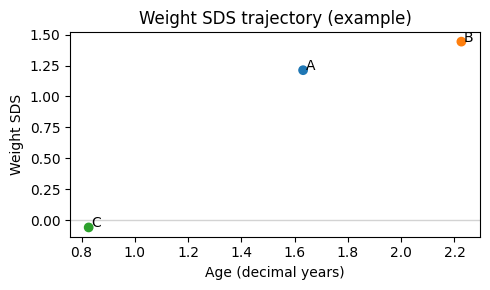

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.axhline(0, color='lightgray', lw=1)
plt.scatter(df['age_decimal_years'], df['weight_sds'], c=['tab:blue','tab:orange','tab:green'])
for _, r in df.iterrows():
    plt.text(r['age_decimal_years']+0.01, r['weight_sds'], r['id'])
plt.xlabel('Age (decimal years)')
plt.ylabel('Weight SDS')
plt.title('Weight SDS trajectory (example)')
plt.tight_layout()
plt.show()

## 4. Export results
You can now export the enriched DataFrame (with SDS & centiles) to CSV for downstream stats or modelling.


In [ ]:
# Export (disabled by default) - uncomment to write
# df.to_csv('example_results.csv', index=False)
print('DataFrame ready; uncomment export line to save to CSV.')

## Chart the results



UK-WHO data does not exist below 23 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO data does not exist below 23 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO data does not exist below 23 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO data does not exist below 23 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO data does not exist below 23 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO length data does not exist in infants below 25 weeks gestation.
UK-WHO data does not exis

AttributeError: PathCollection.set() got an unexpected keyword argument 'text'

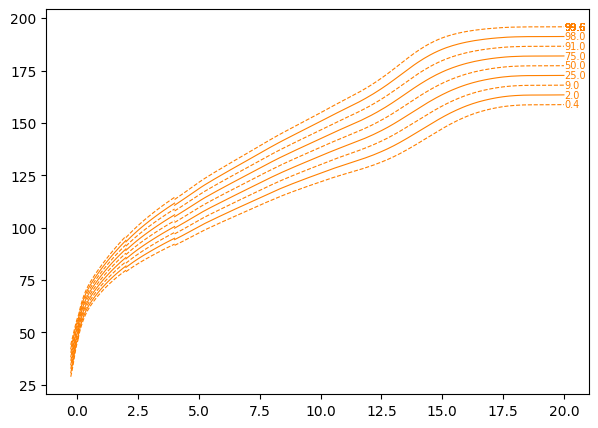

In [ ]:
# python imports
from datetime import date
# 3rd party imports
import matplotlib.pyplot as plt

# RCPCH imports
from rcpchgrowth import create_chart # Create growth chart
from rcpchgrowth import Measurement # Create a child measurement to plot

# Define the child's details
sex = 'female'
dob = date(2012, 6, 15)
md  = date(2020, 2, 1)
height_cm = 135.4

# Create a measurement object for the child
measurement = Measurement(sex=sex, birth_date=dob, measurement_method='height', observation_date=md, observation_value=height_cm, reference='uk-who', gestation_weeks=40, gestation_days=0).measurement

uk_who_chart = create_chart(reference="uk-who", measurement_method="height", sex="male")
uk_90_preterm = uk_who_chart[0]['uk90_preterm']['male']['height']
who_infant    = uk_who_chart[1]['uk_who_infant']['male']['height']
who_child     = uk_who_chart[2]['uk_who_child']['male']['height']
uk90_child    = uk_who_chart[3]['uk90_child']['male']['height']

refs = {
    "uk_90_preterm": uk_90_preterm,
    "who_infant": who_infant,
    "who_child": who_child,
    "uk90_child": uk90_child,
}

# Set a colour
base_color = "#FF8000"

# set the chart size
plt.figure(figsize=(7,5))

# loop through the references (there are 4), then each of their centiles
# in this way we end up with 9 continuous lines made up of 4 sections, one for each reference
# we have to do it this way so that where the references overlap, we can see the transitions
for ref_name, centile_list in refs.items():
    for c in centile_list:
        pts = c["data"]            # list of {x:..., y:..., l:...}
        if not pts:
            continue
        # Ensure ordered by x
        pts_sorted = sorted(pts, key=lambda p: p["x"])
        xs = [p["x"] for p in pts_sorted]
        ys = [p["y"] for p in pts_sorted]
        sds_val = c.get("sds", 0)
        plt.plot(
            xs, ys,
            color=base_color,
            # alpha=0.35 + 0.45*(abs(sds_val) in (0,2,3)),
            linewidth=0.8,
            # some centiles are dashed - by convention one of these is the 50th centile
            # this is to 'deemphasize' the 50th centile line
            linestyle="--" if c.get('centile') in [0.4, 9.0, 50.0, 91.0, 99.6] else "-"
        )
        # Label at end of uk90 reference only (last x). Use 'centile' key.
        if ref_name=="uk90_child":
            cent_label = c.get("centile")
            end_x, end_y = xs[-1], ys[-1]
        # Slight offset to avoid covering line
        plt.text(
            end_x, end_y,
            str(cent_label),
            fontsize=7,
            color=base_color,
            ha="left",
            va="center",
            clip_on=True,
        )
# add the measurement point - there is one for the chronological age, one for the corrected age
# standard practice is for the corrected age to be used and rendered as cross, joined to the chronological
# age which is typically represented as a filled circle
patient_x = measurement["plottable_data"]["centile_data"]["chronological_decimal_age_data"]["x"]
patient_y = measurement["plottable_data"]["centile_data"]["chronological_decimal_age_data"]["y"]
patient_label = f"Chronological Age ({patient_x:.1f} y): {patient_y} cm measured on {measurement['measurement_dates']['observation_date']}"
scatter_point = plt.scatter(patient_x, patient_y, color="#808080", zorder=5)
# Add label with a box and an arrow
plt.annotate(
    patient_label,
    (patient_x, patient_y),
    xytext=(10,10),
    textcoords="offset points",
    bbox=dict(boxstyle="round", fc="w", ec="#666", alpha=0.85),
    arrowprops=dict(arrowstyle="->", color="#666"),
    fontsize=8,
)
# Uncomment this if this is a premature neonate and you want to render the corrected age as a cross alongside the chronological age
# plt.scatter(
#     measurement["plottable_data"]["centile_data"]["corrected_decimal_age_data"]["x"], measurement["plottable_data"]["centile_data"]["corrected_decimal_age_data"]["y"],
#     color="#808080", # Grey
#     zorder=5,
#     label=f"Child Measurement on {measurement['measurement_dates']['observation_date']}",
#     marker="x"
# )

plt.xlabel("Age (years)")
plt.ylabel("Height (cm)")
plt.title("UK-WHO height centile curves")
plt.tight_layout()
plt.show()

In [ ]:
uk_who_chart[0]